# 03_schonungen – Walk-Forward Day-Ahead Simulation (2017–2025)

Dieses Notebook simuliert eine vollständige historische Bidding-Simulation für den Standort **Schonungen**:
Für jeden Tag von 2017 bis 2025 wird mit den 30 Tagen davor neu trainiert und ein 24h-Day-Ahead-Forecast erzeugt.

**Standort:** Schonungen  
**Szenario:** NWP (Wettervorhersagedaten als Hauptfeature)  
**Modelle:** Elastic Net, XGBoost, QGB, QRF  
**Trainingsfenster:** 30 Tage rollierend

## 1. Setup und Imports

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings
import os
import time

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FORECAST_DIR  = PROJECT_ROOT / "results" / "forecasts"
TABLES_DIR    = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR   = PROJECT_ROOT / "results" / "figures"

for d in [FORECAST_DIR, TABLES_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

from src.models import elastic_net
from src.models import xgboost_model
from src.models import quantile_gradient_boosting
from src.models import quantile_regression_forest
from src.data.load_nwp import load_and_merge_nwp, FEATURES_NWP

print("Setup OK | Project root:", PROJECT_ROOT)

Setup OK | Project root: /Users/noahweis/wind_bidding_project


## 2. Parameter

Für anderen Standort: `SELECTED_PLANT` ändern auf `"Schwanfeld"`, `"Trabelsdorf"` oder `"Obbach"`.

In [2]:
SELECTED_PLANT       = "Schonungen"
TRAINING_WINDOW_DAYS = 30
HORIZON_HOURS        = 24
QUANTILES            = [0.10, 0.25, 0.50, 0.75, 0.90]

# Simulationszeitraum (NWP ab 2017-01-01 verfügbar)
SIM_START = pd.Timestamp("2017-02-01")  # mind. 30 Tage nach NWP-Start
SIM_END   = pd.Timestamp("2025-08-31")

# Output-Dateiname pro Standort
OUT_FILE  = FORECAST_DIR / f"predictions_walforward_{SELECTED_PLANT.lower()}.csv"

print(f"Standort:          {SELECTED_PLANT}")
print(f"Simulationszeitraum: {SIM_START.date()} bis {SIM_END.date()}")
print(f"Trainingsfenster:  {TRAINING_WINDOW_DAYS} Tage")
print(f"Output:            {OUT_FILE.name}")

Standort:          Schonungen
Simulationszeitraum: 2017-02-01 bis 2025-08-31
Trainingsfenster:  30 Tage
Output:            predictions_walforward_schonungen.csv


## 3. Daten laden

In [3]:
df_all = pd.read_csv(PROCESSED_DIR / "final_dataset.csv", parse_dates=["timestamp"])

# Standort filtern — ERST filtern, DANN Lags bauen
df = df_all[df_all["site"] == SELECTED_PLANT].copy()
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Datensatz: {df.shape}")
print(f"Zeitraum:  {df['timestamp'].min()} bis {df['timestamp'].max()}")

# NWP-Daten einmergen
df = load_and_merge_nwp(df, site=SELECTED_PLANT)
print(f"Nach NWP-Merge: {df.shape}")

Datensatz: (98357, 11)
Zeitraum:  2014-01-02 00:00:00 bis 2025-08-31 23:00:00
NWP geladen (Schonungen): 75,960 Stunden | 2017-01-01 bis 2025-08-31
Nach NWP-Merge: (98357, 19)


/Users/noahweis/wind_bidding_project/src/data/load_nwp.py:213: UserWarning: 23228 Stunden ohne NWP-Daten (23.6%).
  warnings.warn(


## 4. Feature Engineering

In [4]:
def add_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["energy_lag_24"]      = df["power"].shift(24)
    df["energy_lag_48"]      = df["power"].shift(48)
    df["energy_roll_mean_72"] = df["power"].shift(24).rolling(72).mean()
    return df

df = add_lag_features(df)

TARGET   = "power"
FEATURES = FEATURES_NWP  # NWP + SCADA-Lags + Zeitfeatures

df_model = df.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
print(f"df_model: {df_model.shape}")
print(f"Features ({len(FEATURES)}): {FEATURES}")

df_model: (75129, 22)
Features (15): ['nwp_ws100', 'nwp_wd100', 'nwp_ws10', 'nwp_temp2m', 'nwp_surface_pressure', 'nwp_cloud_cover', 'nwp_wind_power_proxy', 'nwp_wind_ramp', 'energy_lag_24', 'energy_lag_48', 'energy_roll_mean_72', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


## 5. Alle Simulationstage bestimmen

In [5]:
# Alle Tage im Simulationszeitraum mit vollständigen 24h
df_model["date"] = df_model["timestamp"].dt.date
daily_counts = df_model.groupby("date")["timestamp"].count()
full_days = [
    d for d, cnt in daily_counts.items()
    if cnt >= 24
    and pd.Timestamp(d) >= SIM_START
    and pd.Timestamp(d) <= SIM_END
    and pd.Timestamp(d) - pd.Timedelta(days=TRAINING_WINDOW_DAYS) >= df_model["timestamp"].min()
]

print(f"Simulationstage: {len(full_days)}")
print(f"Von: {full_days[0]} bis {full_days[-1]}")
print(f"Erwartete Laufzeit (grob): {len(full_days) * 6 / 60:.0f} Minuten")

Simulationstage: 3074
Von: 2017-02-01 bis 2025-08-31
Erwartete Laufzeit (grob): 307 Minuten


## 6. Walk-Forward-Simulation

Für jeden Tag: 30 Tage Training → 24h Forecast. Fortschritt wird angezeigt.

In [6]:
all_results = []
n_days      = len(full_days)
t_start     = time.time()

for i, target_date in enumerate(full_days):
    target_start = pd.Timestamp(target_date)
    target_end   = target_start + pd.Timedelta(hours=23)
    train_start  = target_start - pd.Timedelta(days=TRAINING_WINDOW_DAYS)
    train_end    = target_start - pd.Timedelta(hours=1)

    train_df = df_model[
        (df_model["timestamp"] >= train_start) &
        (df_model["timestamp"] <= train_end)
    ]
    test_df = df_model[
        (df_model["timestamp"] >= target_start) &
        (df_model["timestamp"] <= target_end)
    ]

    if len(test_df) < 20 or len(train_df) < 24 * 20:
        continue

    X_train = train_df[FEATURES]
    y_train = train_df[TARGET]
    X_test  = test_df[FEATURES]
    y_test  = test_df[TARGET]

    row = {
        "timestamp":       test_df["timestamp"].values,
        "date":            str(target_date),
        "y_true":          y_test.values,
        "persistence_24h": np.clip(X_test["energy_lag_24"].values, 0, None),
    }

    try:
        # Elastic Net
        en_m = elastic_net.train(X_train, y_train)
        row["elastic_net"] = elastic_net.predict(en_m, X_test, clip_negative=True)

        # XGBoost
        xgb_m = xgboost_model.train(
            X_train, y_train,
            n_estimators=150, learning_rate=0.05, max_depth=3,
            min_child_weight=3, random_state=42,
        )
        row["xgboost"] = xgboost_model.predict(xgb_m, X_test, clip_negative=True)

        # QGB
        qgb_m = quantile_gradient_boosting.train(
            X_train, y_train, quantiles=QUANTILES,
            n_estimators=100, learning_rate=0.05, max_depth=3,
            min_samples_leaf=3, random_state=42,
        )
        qgb_preds = quantile_gradient_boosting.predict_all(qgb_m, X_test, clip_negative=True)
        for q in QUANTILES:
            col = f"q{int(q*100):02d}"
            row[f"qgb_{col}"] = qgb_preds[col].values

        # QRF
        qrf_m = quantile_regression_forest.train(X_train, y_train, random_state=42)
        qrf_preds = quantile_regression_forest.predict_all(
            qrf_m, X_test, quantiles=QUANTILES, clip_negative=True
        )
        for q in QUANTILES:
            col = f"q{int(q*100):02d}"
            row[f"qrf_{col}"] = qrf_preds[col].values

    except Exception as e:
        warnings.warn(f"{target_date}: {e}")
        continue

    # Zu DataFrame konvertieren
    day_df = pd.DataFrame({
        k: v for k, v in row.items() if k not in ["timestamp", "date"]
    })
    day_df.insert(0, "timestamp", row["timestamp"])
    day_df.insert(1, "date", row["date"])
    all_results.append(day_df)

    # Fortschritt
    if (i + 1) % 50 == 0 or i == n_days - 1:
        elapsed  = time.time() - t_start
        per_day  = elapsed / (i + 1)
        remaining = per_day * (n_days - i - 1)
        clear_output(wait=True)
        print(f"Fortschritt: {i+1}/{n_days} Tage | "
              f"Vergangen: {elapsed/60:.1f}min | "
              f"Verbleibend: ~{remaining/60:.1f}min")

predictions = pd.concat(all_results, ignore_index=True)
print(f"\nFertig! Shape: {predictions.shape}")
print(f"Zeitraum: {predictions['timestamp'].min()} bis {predictions['timestamp'].max()}")
predictions.head()

Fortschritt: 3074/3074 Tage | Vergangen: 463.3min | Verbleibend: ~0.0min

Fertig! Shape: (73536, 16)
Zeitraum: 2017-02-01 00:00:00 bis 2025-08-31 23:00:00


,timestamp,date,y_true,persistence_24h,elastic_net,xgboost,qgb_q10,qgb_q25,qgb_q50,qgb_q75,qgb_q90,qrf_q10,qrf_q25,qrf_q50,qrf_q75,qrf_q90
0,2017-02-01 00:00:00,2017-02-01,76.700000,265.400000,406.355178,103.362251,0.0,16.085867,25.080571,86.064110,184.237482,5.387255,21.020556,35.212963,76.055357,121.272636
1,2017-02-01 01:00:00,2017-02-01,86.733333,300.300000,274.820787,83.907974,0.0,3.125768,8.699774,17.031201,89.050969,1.766250,6.660000,17.537037,32.982051,63.285281
2,2017-02-01 02:00:00,2017-02-01,12.233333,571.566667,332.787627,73.971077,0.0,12.661802,18.762499,29.784506,82.972432,1.976303,7.835119,20.930980,35.901362,62.202500
3,2017-02-01 03:00:00,2017-02-01,0.933333,357.100000,345.002231,106.315186,0.0,66.315456,128.864763,144.019388,300.270641,59.216919,83.097596,116.437434,165.545272,254.392476
4,2017-02-01 04:00:00,2017-02-01,9.366667,251.866667,401.126458,149.123917,0.0,85.813611,200.136342,232.347394,385.143701,71.482833,101.422494,143.716667,244.883114,345.880000


## 7. Speichern

In [7]:
predictions.to_csv(OUT_FILE, index=False)
print(f"Gespeichert: {OUT_FILE}")
print(f"Stunden: {len(predictions):,} | Tage: {predictions['date'].nunique():,}")

Gespeichert: /Users/noahweis/wind_bidding_project/results/forecasts/predictions_walforward_schonungen.csv
Stunden: 73,536 | Tage: 3,064


## 8. Forecast-Metriken

In [8]:
POINT_COLS = ["persistence_24h", "elastic_net", "xgboost"]

metrics_rows = []
for col in POINT_COLS:
    valid = predictions[col].notna()
    y_t = predictions.loc[valid, "y_true"].values
    y_p = predictions.loc[valid, col].values
    bias = float(np.mean(y_p - y_t))
    metrics_rows.append({
        "model":    col,
        "MAE":      round(mean_absolute_error(y_t, y_p), 2),
        "RMSE":     round(np.sqrt(mean_squared_error(y_t, y_p)), 2),
        "R2":       round(r2_score(y_t, y_p), 4),
        "Bias":     round(bias, 2),
        "Bias_pct": round(bias / float(np.mean(y_t)) * 100, 2),
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values("RMSE")
metrics_df.to_csv(TABLES_DIR / f"metrics_walkforward_{SELECTED_PLANT.lower()}.csv", index=False)
display(metrics_df)

,model,MAE,RMSE,R2,Bias,Bias_pct
1,elastic_net,166.25,255.70,0.7139,8.42,2.28
2,xgboost,164.56,257.42,0.7100,-6.56,-1.77
0,persistence_24h,349.32,533.08,-0.2436,0.25,0.07


## 9. Zeitreihen-Grafik: Forecast vs. Actual (ganzer Zeitraum)

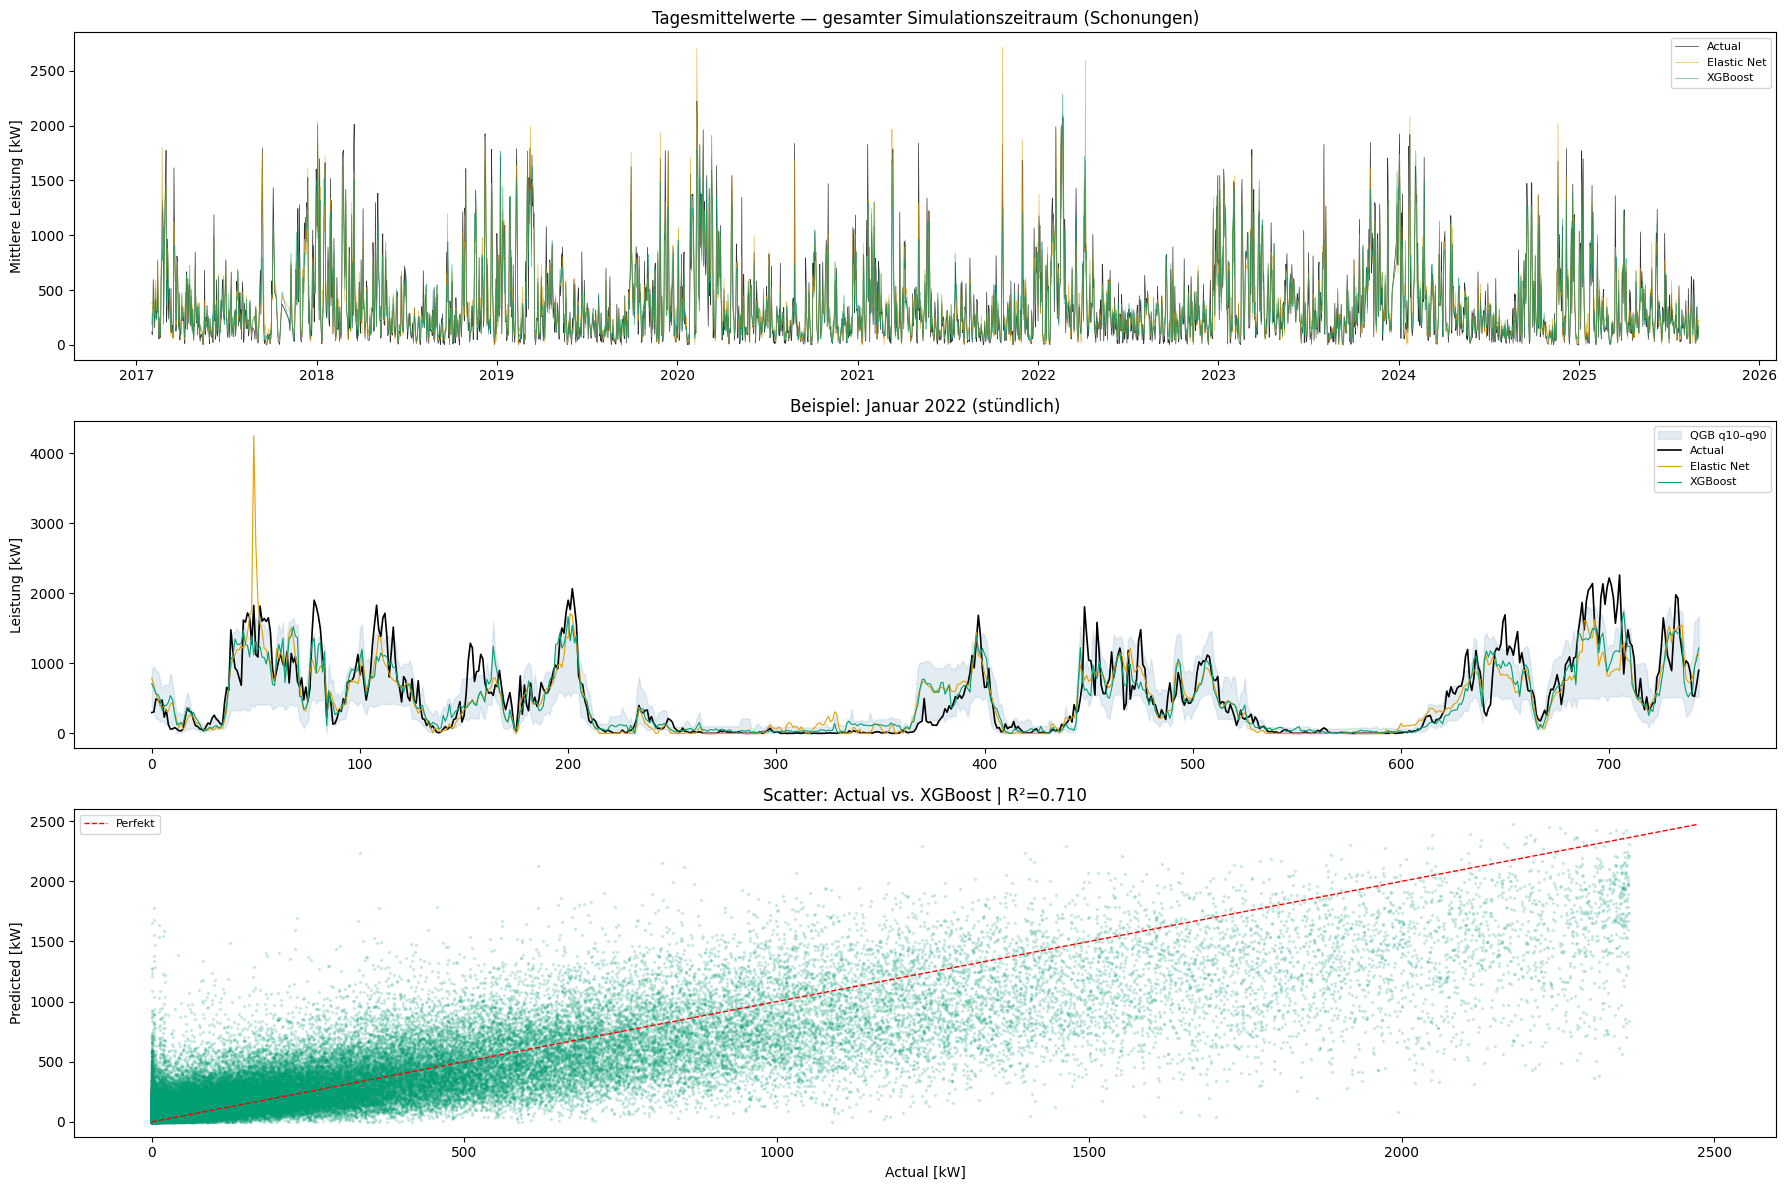

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=False)

# Plot 1: Ganzer Zeitraum (Tagesmittelwerte für Übersicht)
preds_daily = predictions.copy()
preds_daily["date_ts"] = pd.to_datetime(preds_daily["date"])
daily_mean = preds_daily.groupby("date_ts")[["y_true", "elastic_net", "xgboost"]].mean()

ax = axes[0]
ax.plot(daily_mean.index, daily_mean["y_true"],     color="black",   linewidth=0.5, label="Actual", alpha=0.8)
ax.plot(daily_mean.index, daily_mean["elastic_net"], color="#E69F00", linewidth=0.5, label="Elastic Net", alpha=0.7)
ax.plot(daily_mean.index, daily_mean["xgboost"],    color="#009E73", linewidth=0.5, label="XGBoost", alpha=0.7)
ax.set_title(f"Tagesmittelwerte — gesamter Simulationszeitraum ({SELECTED_PLANT})")
ax.set_ylabel("Mittlere Leistung [kW]")
ax.legend(fontsize=8)

# Plot 2: Beispielmonat Januar 2022
ax2 = axes[1]
sample = predictions[
    (pd.to_datetime(predictions["timestamp"]).dt.year == 2022) &
    (pd.to_datetime(predictions["timestamp"]).dt.month == 1)
].sort_values("timestamp")

if not sample.empty:
    hours = range(len(sample))
    ax2.fill_between(hours, sample["qgb_q10"], sample["qgb_q90"], alpha=0.15, color="steelblue", label="QGB q10–q90")
    ax2.plot(hours, sample["y_true"],      color="black",   linewidth=1.2, label="Actual")
    ax2.plot(hours, sample["elastic_net"], color="#E69F00", linewidth=0.8, label="Elastic Net")
    ax2.plot(hours, sample["xgboost"],     color="#009E73", linewidth=0.8, label="XGBoost")
    ax2.set_title("Beispiel: Januar 2022 (stündlich)")
    ax2.set_ylabel("Leistung [kW]")
    ax2.legend(fontsize=8)

# Plot 3: Scatter Actual vs. XGBoost
ax3 = axes[2]
valid = predictions["xgboost"].notna()
y_t = predictions.loc[valid, "y_true"].values
y_p = predictions.loc[valid, "xgboost"].values
ax3.scatter(y_t, y_p, s=2, alpha=0.15, color="#009E73")
lim = max(y_t.max(), y_p.max())
ax3.plot([0, lim], [0, lim], "r--", linewidth=1, label="Perfekt")
ax3.set_title(f"Scatter: Actual vs. XGBoost | R²={r2_score(y_t, y_p):.3f}")
ax3.set_xlabel("Actual [kW]")
ax3.set_ylabel("Predicted [kW]")
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"walkforward_overview_{SELECTED_PLANT.lower()}.png", dpi=200, bbox_inches="tight")
plt.show()

## 10. Pinball Loss (Quantilmodelle)

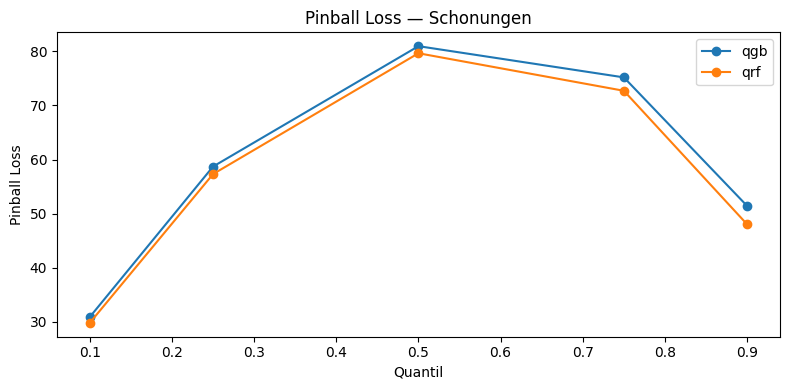

,model,quantile,pinball_loss
0,qgb,0.10,30.9013
1,qgb,0.25,58.6941
2,qgb,0.50,80.9422
3,qgb,0.75,75.1754
4,qgb,0.90,51.4237
5,qrf,0.10,29.8186
6,qrf,0.25,57.3074
7,qrf,0.50,79.6339
8,qrf,0.75,72.6990
9,qrf,0.90,48.0240


In [10]:
pinball_rows = []
for prefix in ["qgb", "qrf"]:
    for q in QUANTILES:
        col = f"{prefix}_q{int(q*100):02d}"
        if col not in predictions.columns:
            continue
        valid = predictions[col].notna()
        y_t   = predictions.loc[valid, "y_true"].values
        y_p   = predictions.loc[valid, col].values
        error = y_t - y_p
        loss  = float(np.mean(np.maximum(q * error, (q-1) * error)))
        pinball_rows.append({"model": prefix, "quantile": q, "pinball_loss": round(loss, 4)})

pinball_df = pd.DataFrame(pinball_rows)
pinball_df.to_csv(TABLES_DIR / f"pinball_walkforward_{SELECTED_PLANT.lower()}.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
for model, grp in pinball_df.groupby("model"):
    ax.plot(grp["quantile"], grp["pinball_loss"], marker="o", label=model)
ax.set_xlabel("Quantil")
ax.set_ylabel("Pinball Loss")
ax.set_title(f"Pinball Loss — {SELECTED_PLANT}")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"pinball_walkforward_{SELECTED_PLANT.lower()}.png", dpi=300, bbox_inches="tight")
plt.show()
display(pinball_df)